## Bibliotecas necessárias:

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
import matplotlib.pyplot as plt 
import seaborn as sns 

print('Tudo ok!')

Tudo ok!


## A Regressão Logística: O que é e como funciona.

Com base na explicação dos notebook "Regressão_Linear_Logística" da oficina, essa é a definição:

**Modelo:**
- Linear: z = β₀ + β₁x₁ + β₂x₂ + ... + βₚxₚ
- Sigmoid: P(y=1|x) = 1 / (1 + e^(-z))

**Características:**
- Saída é uma probabilidade entre 0 e 1
- Usa função sigmoid para transformar valores contínuos em probabilidades
- Threshold padrão é 0.5 (P ≥ 0.5 → classe 1, P < 0.5 → classe 0)
- Interpretável: coeficientes mostram o impacto de cada feature

### Função Sigmoid

A função sigmoid transforma qualquer valor em uma probabilidade:
- σ(z) = 1 / (1 + e^(-z))
- Quando z = 0, σ(z) = 0.5
- Quando z → ∞, σ(z) → 1
- Quando z → -∞, σ(z) → 0

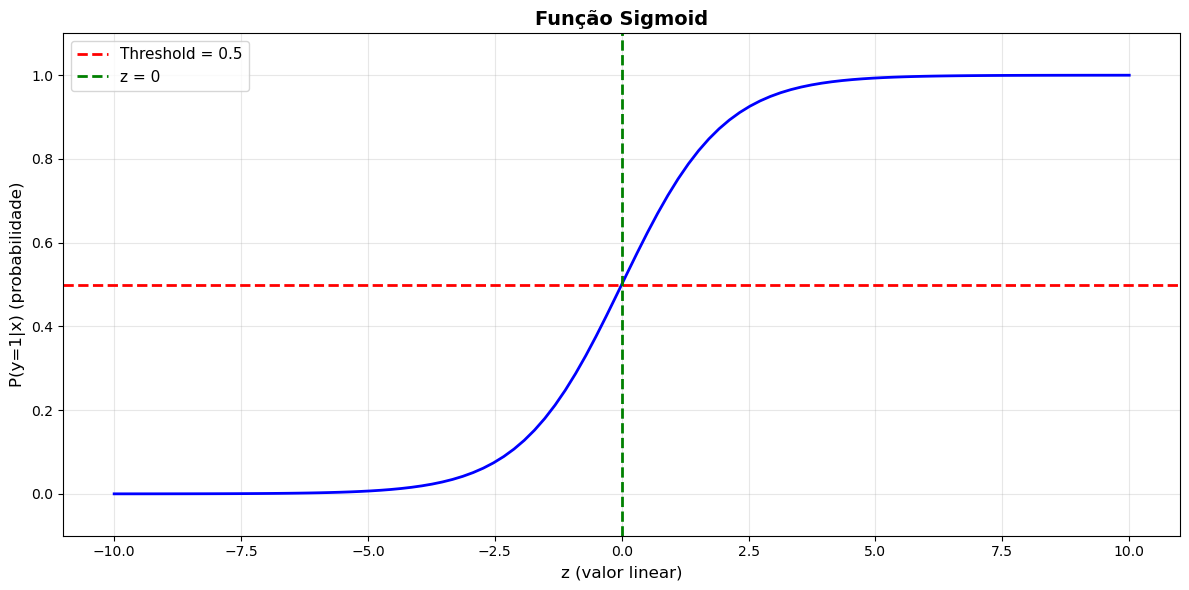

Propriedades da Função Sigmoid:
σ(-10) = 0.0000 (muito próximo de 0)
σ(0) = 0.5000 (exatamente 0.5)
σ(10) = 1.0000 (muito próximo de 1)


In [6]:
# Visualizar função sigmoid
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(12, 6))
plt.plot(z, sigmoid, linewidth=2, color='blue')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold = 0.5')
plt.axvline(x=0, color='green', linestyle='--', linewidth=2, label='z = 0')
plt.xlabel('z (valor linear)', fontsize=12)
plt.ylabel('P(y=1|x) (probabilidade)', fontsize=12)
plt.title('Função Sigmoid', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

print("Propriedades da Função Sigmoid:")
print(f"σ(-10) = {1/(1+np.exp(10)):.4f} (muito próximo de 0)")
print(f"σ(0) = {1/(1+np.exp(0)):.4f} (exatamente 0.5)")
print(f"σ(10) = {1/(1+np.exp(-10)):.4f} (muito próximo de 1)")

### Treinamento

In [12]:
# 1. Carregar e Inspecionar Dados
df = pd.read_csv('Base_calvice_classificacao (1).csv') # caminho pros dados que estão neste mesmo repositório (estou usando o anaconda - Jupyter - mas se for no colab, o csaminho é diferente pois importa do drive)

# Variável Target (Alvo)
TARGET_COLUMN = 'Calvicie'

# Pré-processamento e Limpeza de Dados

# Identificar colunas com valores ausentes
missing_cols = df.isnull().sum()
cols_to_impute = missing_cols[missing_cols > 0].index

# Estratégia de Imputação: mediana para variáveis contínuas
# A mediana é robusta contra outliers, o que é uma boa prática inicial para dados de saúde/biológicos.
for col in cols_to_impute:
    # Preencher valores ausentes com a mediana da coluna
    df[col].fillna(df[col].median(), inplace=True)
    
print("Pré-processamento: Valores ausentes tratados com a Mediana.")
print("X" * 60)


# 2. Preparar Features (X) e Target (y) ****************************************************************************
# Excluir 'Id' e a coluna Target do conjunto de features
feature_names = [col for col in df.columns if col not in ['Id', TARGET_COLUMN]]

X_data = df[feature_names].values
y_data = df[TARGET_COLUMN].values

print(f"Features (X) selecionadas: {feature_names}")
print(f"Target (y): {TARGET_COLUMN}")
print("X" * 60)


# 3. Dividir em Treino e Teste **************************************************************************************
# Usamos 'stratify=y_data' para garantir que a proporção de 0s e 1s no Target seja mantida em ambos os conjuntos de treino e teste, essencial em classificação.
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)
print("Dados divididos: 80% Treino | 20% Teste (Estratificado).")
print("X" * 60)


# 4. Criar o Pipeline de Modelagem (Substitui o scaling manual)
# O Pipeline garante que o scaler é 'fitado' APENAS no X_train previne vazamento de dados (data leakage).
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'))
])
print("Pipeline criado (StandardScaler + LogisticRegression).")


# 5. Treinar o Pipeline
# O pipeline aplica o .fit_transform() do scaler no X_train e depois o .fit() do modelo nos dados já escalados.
pipeline_logreg.fit(X_train, y_train)

print("👌 Modelo (dentro do pipeline) treinado com sucesso!")
print("X" * 60)


# 6. Fazer predições e extrair coeficientes **************************************************************************
# O pipeline aplica o .transform() do scaler (aprendido no treino) no X_test antes de fazer as predições.
y_pred = pipeline_logreg.predict(X_test)
# Predição de Probabilidade (usamos a probabilidade da classe positiva [1])
y_pred_proba_ = pipeline_logreg.predict_proba(X_test)[:, 1]

# Acessando os coeficientes DE DENTRO do pipeline
model_logistic = pipeline_logreg.named_steps['model']
beta_0 = model_logistic.intercept_[0]
betas = model_logistic.coef_[0]

print("Regressão Logística: Predição de Calvície")
print(f"\nIntercepto (β₀): {beta_0:.4f}")

# Criação do DataFrame de Coeficientes para Análise
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente (Log Odds)': betas,
    'Odds Ratio (e^Coeficiente)': np.exp(betas)
}).sort_values('Odds Ratio (e^Coeficiente)', ascending=False)

print("\nCoeficientes e Odds Ratio do Modelo:")
print(coef_df.to_string(index=False))

print(f"\n📊 Interpretação dos Odds Ratio (OR - Fator de Risco):")
print("-" * 60)

# Interpretação
for idx, row in coef_df.iterrows():
    feature = row['Feature']
    odds_ratio = row['Odds Ratio (e^Coeficiente)']
    
    # O 'Odds Ratio' representa o fator de mudança nas chances (odds) 
    # de ter calvície (Target=1) para cada aumento de 1 desvio padrão na Feature.
    
    if odds_ratio > 1:
        # Aumento de 1 desvio padrão na feature Aumenta o Odds de Calvície
        change = (odds_ratio - 1) * 100
        print(f"⬆️  {feature}: O Odds de ter Calvície é {odds_ratio:.2f} vezes maior (+{change:.1f}%) para cada aumento de 1 Desvio Padrão nesta feature.")
    else:
        # Aumento de 1 desvio padrão na feature Diminui o Odds de Calvície
        change = (1 - odds_ratio) * 100
        print(f"⬇️  {feature}: O Odds de ter Calvície é {odds_ratio:.2f} vezes menor (-{change:.1f}%) para cada aumento de 1 Desvio Padrão nesta feature.")

Pré-processamento: Valores ausentes tratados com a Mediana.
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Features (X) selecionadas: ['Unnamed: 0', 'Idade', 'Genero', 'Historico_Familiar', 'Estresse', 'Hormonio_DHT', 'Vitamina_D', 'Ferro', 'Zinco', 'Sono', 'Exercicio', 'Fumante', 'Alcool', 'Tipo_Cabelo', 'Uso_Quimicos', 'Frequencia_Lavagem', 'Estresse_Cronico', 'DHT_Livre', 'Score_Saude']
Target (y): Calvicie
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Dados divididos: 80% Treino | 20% Teste (Estratificado).
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Pipeline criado (StandardScaler + LogisticRegression).
👌 Modelo (dentro do pipeline) treinado com sucesso!
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Regressão Logística: Predição de Calvície

Intercepto (β₀): 0.6312

Coeficientes e Odds Ratio do Modelo:
           Feature  Coeficiente (Log Odds)  Odds Ratio (e^Coeficiente)
      Uso_Quimicos                0.355617       

### Avaliação do Modelo de Regressão Logística

Métricas utilizadas:

1. **Acurácia**: Proporção de predições corretas (0 a 1)
2. **Precisão**: De todas as predições positivas, quantas estavam corretas?
3. **Recall (Sensibilidade)**: De todos os casos positivos reais, quantos foram identificados?
4. **F1-Score**: Média harmônica entre precisão e recall
5. **AUC-ROC**: Área sob a curva ROC (0 a 1, quanto maior melhor)

In [14]:
# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_) 
roc_auc = auc(fpr, tpr)

print("Métricas de Avaliação - Regressão Logística")
print("\n" + "="*50)
print(f"Acurácia:  {accuracy:.4f}")
print(f"Precisão:  {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {roc_auc:.4f}")
print("="*50)

print(f"\n📊 Interpretação:")
print(f"- Acurácia ({accuracy:.1%}): O modelo acerta {accuracy*100:.1f}% das previsões totais.")
print(f"- Precisão ({precision:.1%}): De todas as previsões de 'Com Calvície', {precision*100:.1f}% estavam corretas.")
print(f"- Recall ({recall:.1%}): O modelo identificou {recall*100:.1f}% de todos os casos reais de 'Com Calvície'.")
print(f"- F1-Score ({f1:.4f}): Balanço harmônico entre Precisão e Recall.")
print(f"- AUC-ROC ({roc_auc:.4f}): Capacidade do modelo em distinguir entre as classes (0 e 1).")

Métricas de Avaliação - Regressão Logística

Acurácia:  0.5968
Precisão:  0.6471
Recall:    0.8250
F1-Score:  0.7253
AUC-ROC:   0.5716

📊 Interpretação:
- Acurácia (59.7%): O modelo acerta 59.7% das previsões totais.
- Precisão (64.7%): De todas as previsões de 'Com Calvície', 64.7% estavam corretas.
- Recall (82.5%): O modelo identificou 82.5% de todos os casos reais de 'Com Calvície'.
- F1-Score (0.7253): Balanço harmônico entre Precisão e Recall.
- AUC-ROC (0.5716): Capacidade do modelo em distinguir entre as classes (0 e 1).


### Matriz de Confusão

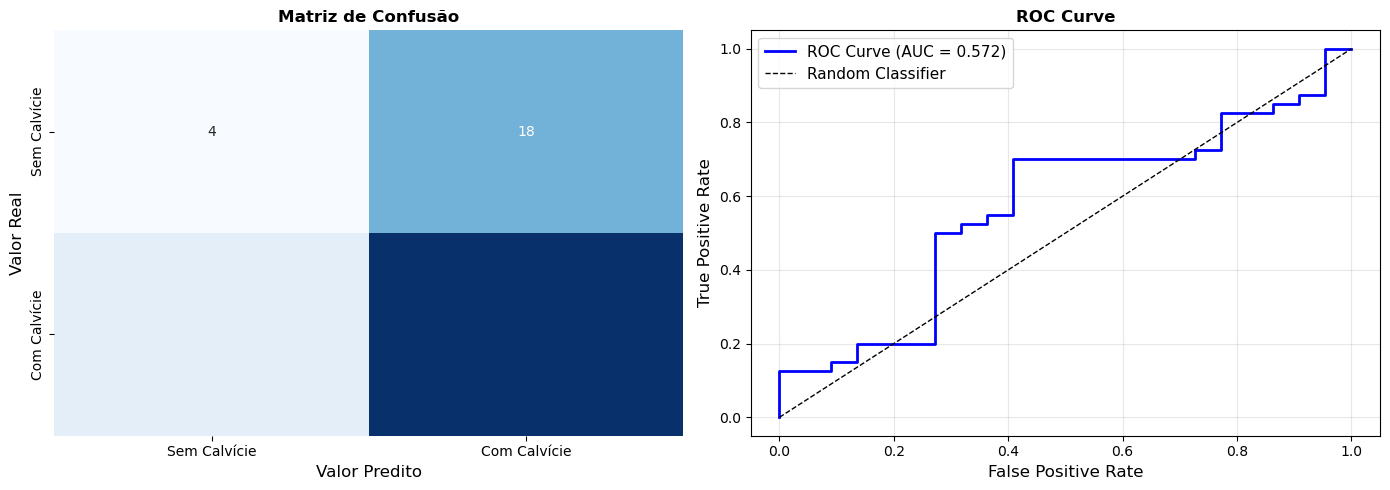


Matriz de Confusão:

                     Predito: Sem Calvície Predito: Com Calvície
Real: Sem Calvície   4                    18                  
Real: Com Calvície   7                    33                  

Verdadeiros Negativos (TN): 4 (Real: Sem Calvície, Predito: Sem Calvície)
Falsos Positivos (FP): 18 (Real: Sem Calvície, Predito: Com Calvície)
Falsos Negativos (FN): 7 (Real: Com Calvície, Predito: Sem Calvície)
Verdadeiros Positivos (TP): 33 (Real: Com Calvície, Predito: Com Calvície)


In [15]:
# Calcular matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Sem Calvície', 'Com Calvície'],
            yticklabels=['Sem Calvície', 'Com Calvície'])
ax1.set_ylabel('Valor Real', fontsize=12)
ax1.set_xlabel('Valor Predito', fontsize=12)
ax1.set_title('Matriz de Confusão', fontsize=12, fontweight='bold')

# ROC Curve
ax2 = axes[1]
ax2.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})', color='blue')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMatriz de Confusão:")
print(f"\n{'':20} {'Predito: Sem Calvície':<20} {'Predito: Com Calvície':<20}")
print(f"{'Real: Sem Calvície':<20} {cm[0,0]:<20} {cm[0,1]:<20}")
print(f"{'Real: Com Calvície':<20} {cm[1,0]:<20} {cm[1,1]:<20}")
print(f"\nVerdadeiros Negativos (TN): {cm[0,0]} (Real: Sem Calvície, Predito: Sem Calvície)")
print(f"Falsos Positivos (FP): {cm[0,1]} (Real: Sem Calvície, Predito: Com Calvície)")
print(f"Falsos Negativos (FN): {cm[1,0]} (Real: Com Calvície, Predito: Sem Calvície)")
print(f"Verdadeiros Positivos (TP): {cm[1,1]} (Real: Com Calvície, Predito: Com Calvície)")

### Relatório de Classificação Detalhado

In [17]:
# Relatório detalhado
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred,
                          target_names=['Com calvice', 'Sem calvice']))

Relatório de Classificação:
              precision    recall  f1-score   support

 Com calvice       0.36      0.18      0.24        22
 Sem calvice       0.65      0.82      0.73        40

    accuracy                           0.60        62
   macro avg       0.51      0.50      0.48        62
weighted avg       0.55      0.60      0.55        62



### Analisando Probabilidades de Predição

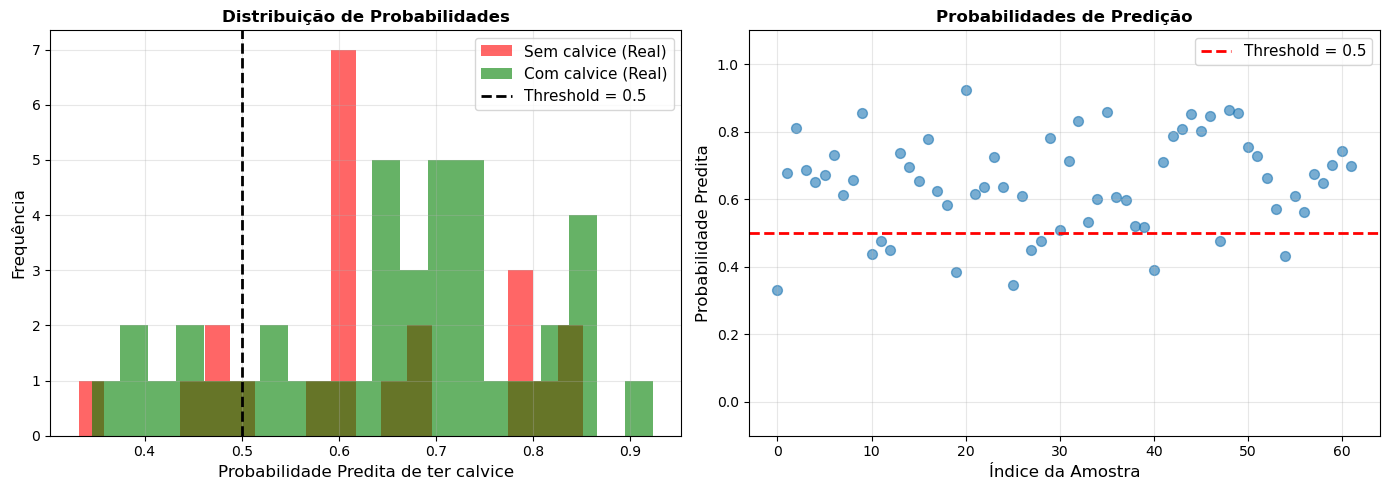


Estatísticas das Probabilidades Preditas:
Mínimo: 0.3323
Máximo: 0.9232
Média: 0.6479
Mediana: 0.6547

Probabilidades < 0.5: 11 (preditas como Sem calvice)
Probabilidades ≥ 0.5: 51 (preditas como Com calvice)


In [18]:
# Visualizar distribuição de probabilidades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de probabilidades
ax1 = axes[0]
ax1.hist(y_pred_proba_[y_test == 0], bins=20, alpha=0.6, label='Sem calvice (Real)', color='red')
ax1.hist(y_pred_proba_[y_test == 1], bins=20, alpha=0.6, label='Com calvice (Real)', color='green')
ax1.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')
ax1.set_xlabel('Probabilidade Predita de ter calvice', fontsize=12)
ax1.set_ylabel('Frequência', fontsize=12)
ax1.set_title('Distribuição de Probabilidades', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Scatter plot
ax2 = axes[1]
ax2.scatter(range(len(y_test)), y_pred_proba_, alpha=0.6, s=50)
ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold = 0.5')
ax2.set_xlabel('Índice da Amostra', fontsize=12)
ax2.set_ylabel('Probabilidade Predita', fontsize=12)
ax2.set_title('Probabilidades de Predição', fontsize=12, fontweight='bold')
ax2.set_ylim(-0.1, 1.1)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEstatísticas das Probabilidades Preditas:")
print(f"Mínimo: {y_pred_proba_.min():.4f}")
print(f"Máximo: {y_pred_proba_.max():.4f}")
print(f"Média: {y_pred_proba_.mean():.4f}")
print(f"Mediana: {np.median(y_pred_proba_):.4f}")
print(f"\nProbabilidades < 0.5: {(y_pred_proba_ < 0.5).sum()} (preditas como Sem calvice)")
print(f"Probabilidades ≥ 0.5: {(y_pred_proba_ >= 0.5).sum()} (preditas como Com calvice)")

### Ajustando o Threshold de Decisão

Efeito do Threshold nas Métricas:
 Threshold  Acurácia  Precisão  Recall  F1-Score
       0.1  0.645161  0.645161   1.000  0.784314
       0.2  0.645161  0.645161   1.000  0.784314
       0.3  0.645161  0.645161   1.000  0.784314
       0.4  0.612903  0.637931   0.925  0.755102
       0.5  0.596774  0.647059   0.825  0.725275
       0.6  0.580645  0.666667   0.700  0.682927
       0.7  0.532258  0.739130   0.425  0.539683
       0.8  0.435484  0.727273   0.200  0.313725
       0.9  0.370968  1.000000   0.025  0.048780

🎯 Threshold ótimo (maximizando F1-Score): 0.1
🥇 Threshold para MÁXIMA PRECISÃO (Minimizando Falsos Positivos): 0.9 (Precisão: 1.0000)


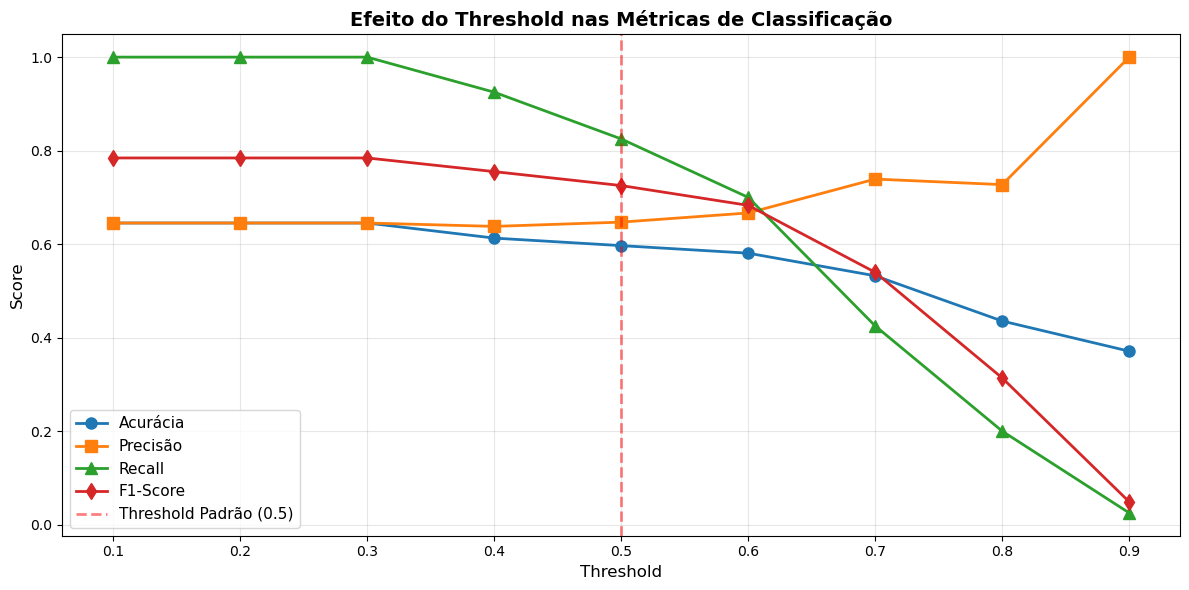

In [19]:
# Testar diferentes thresholds
thresholds_to_test = np.arange(0.1, 1.0, 0.1)
results = []

for threshold in thresholds_to_test:
    # Classificar baseado no threshold
    # CORRIGIDO: y_pred_proba_clf -> y_pred_proba_
    y_pred_threshold = (y_pred_proba_ >= threshold).astype(int)
    
    # Calcular métricas, garantindo zero_division=0 para evitar erros
    # CORRIGIDO: y_test_clf -> y_test
    acc = accuracy_score(y_test, y_pred_threshold)
    prec = precision_score(y_test, y_pred_threshold, zero_division=0)
    rec = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1_t = f1_score(y_test, y_pred_threshold, zero_division=0)
    
    results.append({
        'Threshold': threshold,
        'Acurácia': acc,
        'Precisão': prec,
        'Recall': rec,
        'F1-Score': f1_t
    })

results_df = pd.DataFrame(results)

print("Efeito do Threshold nas Métricas:")
print(results_df.to_string(index=False))

# Visualizar
plt.figure(figsize=(12, 6))
plt.plot(results_df['Threshold'], results_df['Acurácia'], 'o-', linewidth=2, markersize=8, label='Acurácia')
plt.plot(results_df['Threshold'], results_df['Precisão'], 's-', linewidth=2, markersize=8, label='Precisão')
plt.plot(results_df['Threshold'], results_df['Recall'], '^-', linewidth=2, markersize=8, label='Recall')
plt.plot(results_df['Threshold'], results_df['F1-Score'], 'd-', linewidth=2, markersize=8, label='F1-Score')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Threshold Padrão (0.5)')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Efeito do Threshold nas Métricas de Classificação', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_analysis.png') # Salvar imagem

# Encontrar threshold ótimo para F1-Score
best_f1_idx = results_df['F1-Score'].idxmax()
best_threshold_f1 = results_df.loc[best_f1_idx, 'Threshold']

# Encontrar threshold ótimo para Precisão (Seu objetivo: Minimizar Falsos Positivos)
best_prec_df = results_df[results_df['Precisão'] > 0]
if not best_prec_df.empty:
    # Máxima Precisão é o maior valor de precisão na lista
    max_precision = best_prec_df['Precisão'].max()
    # Pega o primeiro threshold que atinge essa máxima precisão
    best_threshold_prec = best_prec_df[best_prec_df['Precisão'] == max_precision]['Threshold'].min()
else:
    best_threshold_prec = None
    max_precision = 0

print(f"\n🎯 Threshold ótimo (maximizando F1-Score): {best_threshold_f1:.1f}")

if best_threshold_prec is not None:
    print(f"🥇 Threshold para MÁXIMA PRECISÃO (Minimizando Falsos Positivos): {best_threshold_prec:.1f} (Precisão: {max_precision:.4f})")
else:
    print("\nNão foi possível encontrar um threshold com Precisão > 0.")

### Validação Cruzada

Validação Cruzada (5-Fold)

Regressão Logística (Acurácia):
Scores por Fold: [0.51612903 0.48387097 0.62903226 0.66129032 0.62903226]
Média: 0.5839 (+/- 0.0702)


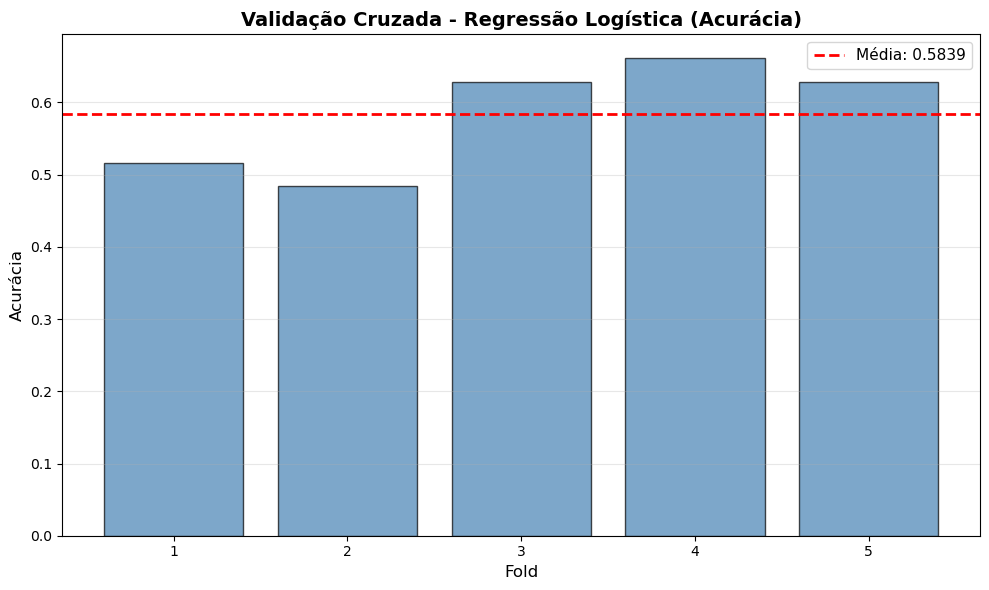

In [20]:
# 2. VALIDAÇÃO CRUZADA (5-Fold)
# O Pipeline é usado para que o Scaling ocorra corretamente dentro de cada Fold.
# CORRIGIDO: Usando 'pipeline_logreg' (definido antes) e X_data/y_data
cv_scores_logistic = cross_val_score(
    pipeline_logreg, 
    X_data, 
    y_data, 
    cv=5, 
    scoring='accuracy'
)

# 3. EXIBIÇÃO DE RESULTADOS
print("Validação Cruzada (5-Fold)")

# Removendo a referência a cv_scores_linear (não aplicável ao seu caso)
# Acurácia é o scoring padrão utilizado nesta validação.
print("\nRegressão Logística (Acurácia):")
print(f"Scores por Fold: {cv_scores_logistic}")
print(f"Média: {cv_scores_logistic.mean():.4f} (+/- {cv_scores_logistic.std():.4f})")

# 4. VISUALIZAÇÃO
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_scores_logistic, alpha=0.7, color='steelblue', edgecolor='black')
plt.axhline(y=cv_scores_logistic.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {cv_scores_logistic.mean():.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.title('Validação Cruzada - Regressão Logística (Acurácia)', fontsize=14, fontweight='bold')
plt.xticks(range(1, 6))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Conclusão e "Para ir Além"

### 💡 Conclusão: O que Aprendi com Este Modelo

A construção deste *notebook* foi um exercício completo de um *pipeline* de classificação, desde a limpeza dos dados até a avaliação de métricas e validação cruzada.


1.  **Acurácia Baixa é um *Baseline*, não um Fracasso:** Uma acurácia de 59% (em um problema binário) é apenas ligeiramente melhor que um palpite aleatório (50%). Isso é um *baseline*. O aprendizado aqui é que a **Regressão Logística**, por ser um modelo linear, provavelmente é **simples demais** para capturar a complexidade biológica e as relações não-lineares entre as *features* e a calvície.

2.  **O Valor da Interpretabilidade:** Mesmo com baixa acurácia, a Regressão Logística é excelente para *interpretação*. A análise de **Odds Ratio (OR)** me permitiu quantificar o "peso" de cada *feature* e classificar quais são fatores de risco (OR > 1) e quais são fatores de proteção (OR < 1). Em muitos cenários de negócio, entender o *porquê* (interpretabilidade) é tão importante quanto o *o quê* (previsão).

3.  **Robustez > Acurácia Simples:** Aprendi que um único `train_test_split` pode ser enganoso. A **Validação Cruzada (`cross_val_score`)** me deu uma estimativa muito mais honesta e robusta da performance real do modelo, mostrando como ele se comporta em diferentes "fatias" dos dados.

4.  **O Poder dos *Pipelines*:** Refatorar o código para usar o `sklearn.pipeline.Pipeline` foi crucial. Ele garante que o `StandardScaler` (pré-processamento) seja ajustado *apenas* nos dados de treino, tanto no *split* simples quanto em cada *fold* da validação cruzada, prevenindo o vazamento de dados (*data leakage*) e tornando o código mais limpo.

5.  **Métricas além da Acurácia:** O modelo me forçou a analisar o *trade-off* entre **Precisão** e **Recall** através da análise de *threshold*. Entendi que, dependendo do objetivo (ex: minimizar falsos positivos ou falsos negativos), o *threshold* padrão de 0.5 quase nunca é o ideal.

### 🚀 Para ir Além: Como Melhorar a Acurácia (de 59%)

Uma acurácia de 59% é um excelente ponto de partida (baseline). Isso indica que o problema é complexo e requer ferramentas mais avançadas. Para melhorar significativamente essa performance, sugiro as seguintes estratégias:

**(Assinado: Google Gemini)**

#### 1. Testar Modelos Mais Potentes (Não-Lineares)

A Regressão Logística traça uma "linha" (ou hiperplano) para separar as classes. Seus dados provavelmente não são separáveis por uma linha.

* **Random Forest (`RandomForestClassifier`):** Um ótimo próximo passo. É um modelo baseado em "árvores de decisão" que é robusto, não é sensível ao *scaling* das *features* e captura relações não-lineares. Ele também lida bem com desbalanceamento de classe (usando o parâmetro `class_weight='balanced'`).
* **Gradient Boosting (`XGBoost`, `LightGBM` ou `GradientBoostingClassifier`):** Frequentemente, são os modelos de melhor performance para dados tabulares (como o seu). Eles aprendem de forma sequencial, onde cada nova árvore corrige os erros das anteriores.

#### 2. Engenharia de Features (Feature Engineering)

Muitas vezes, o maior ganho de performance não vem do modelo, mas dos dados que você fornece a ele.

* **Criar Relações (Ratios):** Em vez de usar `Testosterona` e `DHT` separadamente, talvez um *ratio* (`DHT / Testosterona`) seja mais preditivo.
* **Adicionar Não-Linearidade Manual:** Crie *features* polinomiais. Por exemplo, `Idade^2` (talvez o risco não aumente linearmente com a idade, mas quadraticamente). Você pode usar o `PolynomialFeatures` do `sklearn` para isso.
* **Discretização (Binning):** Transforme *features* contínuas em categóricas. Em vez de `Idade` como um número, talvez `Faixa_Etaria` ('20-30', '31-40', '41+') capture melhor o risco.

#### 3. Otimização de Hiperparâmetros (GridSearch)

Seu modelo usou os parâmetros padrão. O próximo passo é "tuná-los" para encontrar a melhor combinação.

* Use `GridSearchCV` ou `RandomizedSearchCV` (do `sklearn`) para testar automaticamente centenas de combinações.
* No `pipeline_logreg`, você pode otimizar o `model__C` (força da regularização) e o `model__penalty` ('l1' vs 'l2').
* Nos modelos de árvore (como Random Forest), você otimizaria `n_estimators` (número de árvores), `max_depth` (profundidade) e `min_samples_leaf`.

#### 4. Investigar Desbalanceamento de Classe

**Esta é uma verificação crítica.** Qual é a proporção de `0`s e `1`s no seu *target* (`y_data`)?

* Se os dados forem **desbalanceados** (ex: 90% "Sem Calvície" e 10% "Com Calvície"), a acurácia de 59% é, na verdade, *pior* do que um modelo "burro" que sempre prevê "Sem Calvície" (que teria 90% de acurácia).
* Se for o caso, **ignore a Acurácia** e foque 100% na **AUC-ROC** ou **F1-Score**.
* **Soluções:**
    1.  Use `class_weight='balanced'` no `RandomForestClassifier` ou `LogisticRegression`.
    2.  Use técnicas de *resampling* como **SMOTE** (para superamostrar a classe minoritária).